# ISLES 2022 — Ischemic Stroke Lesion Segmentation with nnU-Net v2

**End-to-end pipeline: exploratory data analysis, multi-modal nnU-Net v2 training, inference, and evaluation on the ISLES'22 challenge dataset.**

---

## Overview

This notebook implements a complete, reproducible pipeline for automated ischemic
stroke lesion segmentation from multi-parametric MRI, using the self-configuring
[nnU-Net v2](https://github.com/MIC-DKFZ/nnUNet) framework.

| | |
|---|---|
| **Dataset** | [ISLES 2022](https://doi.org/10.5281/zenodo.7153326) (Hernandez Petzsche et al., 2022) |
| **Modalities** | DWI, ADC, FLAIR (multi-channel input) |
| **Cases** | 250 expert-annotated multi-center MRI cases |
| **Framework** | nnU-Net v2 (Isensee et al., 2021, *Nature Methods*) |
| **Task** | Binary voxel-wise infarct segmentation |

## Pipeline

1. Environment setup
2. Data discovery (BIDS-style layout, auto-detected)
3. Exploratory Data Analysis
4. Conversion to nnU-Net raw dataset format
5. Preprocessing & fingerprinting
6. Training
7. Inference & quantitative evaluation (Dice)
8. Qualitative visualization

## Citation

If you use the ISLES 2022 dataset, please cite:

> Hernandez Petzsche, M.R., de la Rosa, E., Hanning, U. *et al.* ISLES 2022: A
> multi-center magnetic resonance imaging stroke lesion segmentation dataset.
> *Sci Data* **9**, 762 (2022). https://doi.org/10.1038/s41597-022-01875-5

If you use nnU-Net, please cite:

> Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021).
> nnU-Net: a self-configuring method for deep learning-based biomedical image
> segmentation. *Nature Methods*, 18(2), 203-211.

## License note

The ISLES 2022 dataset is released under **CC BY 4.0** — attribution to the
original authors is required in any derivative work, including this repository.


## 1. Environment Setup

In [ ]:
!pip install nnunetv2 nibabel SimpleITK -q

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import zipfile
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import SimpleITK as sitk

plt.rcParams['figure.facecolor'] = 'white'
random.seed(42)
np.random.seed(42)


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 9.9 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# --- Point this to your extracted ISLES-2022 folder on Drive ---
DATASET_ROOT = '/content/drive/MyDrive/Stroke-Dataset'

import zipfile

ZIP_PATH = '/content/drive/MyDrive/Stroke-Dataset/ISLES-2022.zip'  # gerçek zip yolunu buraya yaz
EXTRACT_DIR = '/content/ISLES-2022'  # local'e aç, Drive'a değil — çok daha hızlı

os.makedirs(EXTRACT_DIR, exist_ok=True)
print("Extracting...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Extract sonrası gerçek kökü otomatik bul (bir üst klasör olabilir diye)
DATASET_ROOT = next(
    (p.parent for p in Path(EXTRACT_DIR).rglob('sub-strokecase*') if p.is_dir()),
    Path(EXTRACT_DIR)
)
print("Gerçek DATASET_ROOT:", DATASET_ROOT)

subject_dirs = sorted([p for p in Path(DATASET_ROOT).glob('sub-strokecase*') if p.is_dir()])
print(f"Subject folders found: {len(subject_dirs)}")


Extracting...
Gerçek DATASET_ROOT: /content/ISLES-2022/ISLES-2022
Subject folders found: 250


## 2. Data Discovery

ISLES 2022 follows a BIDS-inspired layout:

```
ISLES-2022/
├── sub-strokecase0001/
│   └── ses-0001/
│       ├── sub-strokecase0001_ses-0001_dwi.nii.gz
│       ├── sub-strokecase0001_ses-0001_adc.nii.gz
│       └── sub-strokecase0001_ses-0001_flair.nii.gz
├── ...
└── derivatives/
    └── sub-strokecase0001/
        └── ses-0001/
            └── sub-strokecase0001_ses-0001_msk.nii.gz
```

The cell below discovers files by **keyword matching** rather than a hardcoded
path, so it tolerates minor naming variations across dataset releases.

In [ ]:
def find_by_keyword(case_dir, keyword):
    matches = [p for p in Path(case_dir).rglob('*.nii*') if keyword.lower() in p.name.lower()]
    return matches[0] if matches else None

# Subject folders follow the `sub-strokecaseXXXX` convention
subject_dirs = sorted([p for p in Path(DATASET_ROOT).glob('sub-strokecase*') if p.is_dir()])
derivatives_dir = Path(DATASET_ROOT) / 'derivatives'

print(f"Subject folders found: {len(subject_dirs)}")
print(f"Derivatives folder present: {derivatives_dir.exists()}")
if subject_dirs:
    print("Example subject folder contents:")
    for p in sorted(subject_dirs[0].rglob('*.nii*')):
        print(" -", p.relative_to(subject_dirs[0]))


Subject folders found: 250
Derivatives folder present: True
Example subject folder contents:
 - ses-0001/anat/sub-strokecase0001_ses-0001_FLAIR.nii.gz
 - ses-0001/dwi/sub-strokecase0001_ses-0001_adc.nii.gz
 - ses-0001/dwi/sub-strokecase0001_ses-0001_dwi.nii.gz


In [ ]:
def collect_case(subject_dir, derivatives_root):
    case_id = subject_dir.name  # e.g. 'sub-strokecase0001'
    dwi = find_by_keyword(subject_dir, 'dwi')
    adc = find_by_keyword(subject_dir, 'adc')
    flair = find_by_keyword(subject_dir, 'flair')

    mask = None
    if derivatives_root.exists():
        case_derivatives_dir = derivatives_root / case_id
        if case_derivatives_dir.exists():
            for kw in ['msk', 'mask', 'lesion', 'seg']:
                mask = find_by_keyword(case_derivatives_dir, kw)
                if mask is not None:
                    break

    return {'case_id': case_id, 'dwi': dwi, 'adc': adc, 'flair': flair, 'mask': mask}

cases = [collect_case(d, derivatives_dir) for d in subject_dirs]
cases_df = pd.DataFrame(cases)

for col in ['dwi', 'adc', 'flair', 'mask']:
    cases_df[f'has_{col}'] = cases_df[col].notna()

print(cases_df[['case_id', 'has_dwi', 'has_adc', 'has_flair', 'has_mask']].sum(numeric_only=True))
print(f"\nComplete cases (all 4 files present): {cases_df[['has_dwi','has_adc','has_flair','has_mask']].all(axis=1).sum()} / {len(cases_df)}")

complete_cases = cases_df[cases_df[['has_dwi', 'has_adc', 'has_flair', 'has_mask']].all(axis=1)].reset_index(drop=True)
complete_cases.head(10)


has_dwi      250
has_adc      250
has_flair    250
has_mask     250
dtype: int64

Complete cases (all 4 files present): 250 / 250


,case_id,dwi,adc,flair,mask,has_dwi,has_adc,has_flair,has_mask
0,sub-strokecase0001,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
1,sub-strokecase0002,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
2,sub-strokecase0003,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
3,sub-strokecase0004,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
4,sub-strokecase0005,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
5,sub-strokecase0006,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
6,sub-strokecase0007,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
7,sub-strokecase0008,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
8,sub-strokecase0009,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True
9,sub-strokecase0010,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/sub-strokecase0...,/content/ISLES-2022/ISLES-2022/derivatives/sub...,True,True,True,True


## 3. Exploratory Data Analysis

In [ ]:
def load_sitk(path):
    img = sitk.ReadImage(str(path))
    arr = sitk.GetArrayFromImage(img)  # (z, y, x)
    spacing = img.GetSpacing()          # (x, y, z)
    return arr, spacing, img

def robust_normalize(arr, low_pct=1, high_pct=99):
    """Percentile-based contrast stretch for MRI display (no fixed HU window, unlike CT)."""
    lo, hi = np.percentile(arr[arr > 0], [low_pct, high_pct]) if np.any(arr > 0) else (arr.min(), arr.max())
    clipped = np.clip(arr, lo, hi)
    if hi - lo < 1e-6:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((clipped - lo) / (hi - lo) * 255).astype(np.uint8)


In [ ]:
records = []
for _, row in complete_cases.iterrows():
    dwi_arr, dwi_spacing, _ = load_sitk(row['dwi'])
    mask_arr, mask_spacing, _ = load_sitk(row['mask'])

    voxel_vol_mm3 = float(np.prod(mask_spacing))
    lesion_voxels = int((mask_arr > 0).sum())

    records.append({
        'case_id': row['case_id'],
        'shape': dwi_arr.shape,
        'spacing_mm': tuple(round(s, 2) for s in dwi_spacing),
        'lesion_voxel_count': lesion_voxels,
        'lesion_volume_ml': round(lesion_voxels * voxel_vol_mm3 / 1000, 2),
        'has_lesion': lesion_voxels > 0,
    })

eda_df = pd.DataFrame(records)
print(f"Total cases processed: {len(eda_df)}")
print(f"Cases with a labeled lesion: {eda_df['has_lesion'].sum()} / {len(eda_df)}")
eda_df.head(10)


Total cases processed: 250
Cases with a labeled lesion: 247 / 250


,case_id,shape,spacing_mm,lesion_voxel_count,lesion_volume_ml,has_lesion
0,sub-strokecase0001,"(73, 112, 112)","(2.0, 2.0, 2.0)",835,6.68,True
1,sub-strokecase0002,"(72, 112, 112)","(2.0, 2.0, 2.0)",118,0.94,True
2,sub-strokecase0003,"(72, 112, 112)","(2.0, 2.0, 2.0)",3873,30.98,True
3,sub-strokecase0004,"(72, 112, 112)","(2.0, 2.0, 2.0)",281,2.25,True
4,sub-strokecase0005,"(72, 112, 112)","(2.0, 2.0, 2.0)",728,5.82,True
5,sub-strokecase0006,"(72, 112, 112)","(2.0, 2.0, 2.0)",5,0.04,True
6,sub-strokecase0007,"(73, 112, 112)","(2.0, 2.0, 2.0)",439,3.51,True
7,sub-strokecase0008,"(72, 112, 112)","(2.0, 2.0, 2.0)",94,0.75,True
8,sub-strokecase0009,"(73, 112, 112)","(2.0, 2.0, 2.0)",523,4.18,True
9,sub-strokecase0010,"(72, 112, 112)","(2.0, 2.0, 2.0)",421,3.37,True


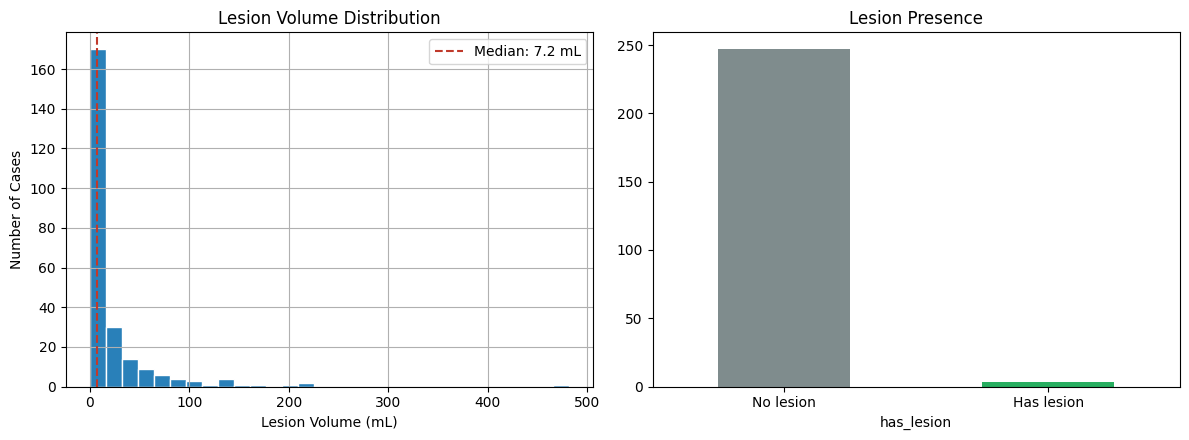

Saved: /content/drive/MyDrive/teknofest-dataset/isles22_eda_summary.csv


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

eda_df.loc[eda_df['has_lesion'], 'lesion_volume_ml'].hist(bins=30, ax=axes[0], color='#2980b9', edgecolor='white')
axes[0].set_xlabel('Lesion Volume (mL)')
axes[0].set_ylabel('Number of Cases')
axes[0].set_title('Lesion Volume Distribution')

axes[0].axvline(eda_df.loc[eda_df['has_lesion'], 'lesion_volume_ml'].median(), color='#c0392b', linestyle='--',
                label=f"Median: {eda_df.loc[eda_df['has_lesion'], 'lesion_volume_ml'].median():.1f} mL")
axes[0].legend()

eda_df['has_lesion'].value_counts().plot(kind='bar', ax=axes[1], color=['#7f8c8d', '#27ae60'])
axes[1].set_title('Lesion Presence')
axes[1].set_xticklabels(['No lesion', 'Has lesion'], rotation=0)

plt.tight_layout()
plt.show()

out_path = '/content/drive/MyDrive/teknofest-dataset/isles22_eda_summary.csv'
eda_df.to_csv(out_path, index=False)
print("Saved:", out_path)


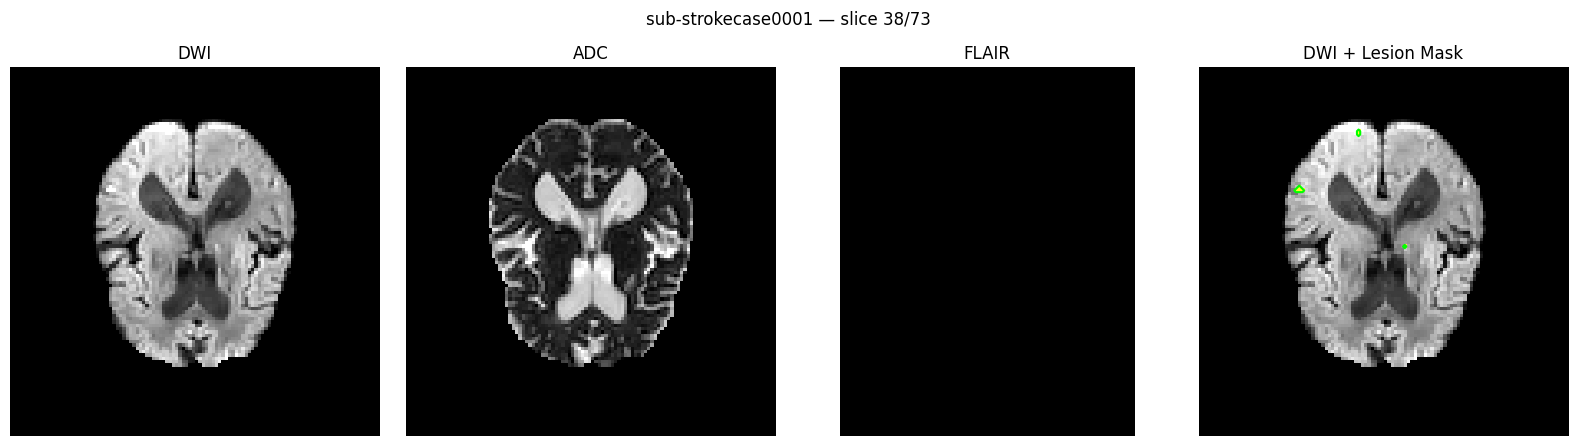

In [ ]:
def show_case(case_row, slice_frac=0.5):
    dwi_arr, _, _ = load_sitk(case_row['dwi'])
    adc_arr, _, _ = load_sitk(case_row['adc'])
    flair_arr, _, _ = load_sitk(case_row['flair'])
    mask_arr, _, _ = load_sitk(case_row['mask'])

    n_slices = dwi_arr.shape[0]
    if mask_arr.sum() > 0:
        lesion_slices = np.where(mask_arr.sum(axis=(1, 2)) > 0)[0]
        idx = int(lesion_slices[len(lesion_slices) // 2])
    else:
        idx = int(n_slices * slice_frac)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    titles = ['DWI', 'ADC', 'FLAIR', 'DWI + Lesion Mask']
    volumes = [dwi_arr, adc_arr, flair_arr]

    for ax, vol, title in zip(axes[:3], volumes, titles[:3]):
        ax.imshow(robust_normalize(vol[idx]), cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    axes[3].imshow(robust_normalize(dwi_arr[idx]), cmap='gray')
    msl = mask_arr[idx]
    if msl.max() > 0:
        axes[3].imshow(np.ma.masked_where(msl == 0, msl), cmap='spring', alpha=0.85, vmin=0, vmax=1)
        axes[3].contour(msl, levels=[0.5], colors='lime', linewidths=1.5)
    axes[3].set_title(titles[3])
    axes[3].axis('off')

    plt.suptitle(f"{case_row['case_id']} — slice {idx}/{n_slices}")
    plt.tight_layout()
    plt.show()

lesion_case_ids = eda_df.loc[eda_df['has_lesion'], 'case_id'].tolist()
example_row = complete_cases[complete_cases['case_id'] == lesion_case_ids[0]].iloc[0]
show_case(example_row)


## 4. Conversion to nnU-Net Format

DWI and ADC originate from the same diffusion acquisition and share a common
grid. FLAIR is a separate sequence and, per the dataset authors, is **released
in native space** (i.e. not guaranteed to be pixel-aligned with DWI after
skull-stripping). We resample FLAIR onto the DWI grid with SimpleITK before
stacking channels.

> **Limitation, stated explicitly for transparency:** this is a grid resample,
> not a full rigid/affine registration. For a research-grade result you may
> want to add a proper registration step (e.g. with ANTsPy or Elastix) before
> resampling. We flag this rather than silently assuming perfect alignment.

In [ ]:
def resample_to_reference(moving_img, reference_img):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference_img)
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(0)
    return resampler.Execute(moving_img)

def resample_mask_to_reference(moving_img, reference_img):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(reference_img)
    resampler.SetInterpolator(sitk.sitkNearestNeighbor)  # preserve binary labels
    resampler.SetDefaultPixelValue(0)
    return resampler.Execute(moving_img)


In [ ]:
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/drive/MyDrive/teknofest-dataset/nnUNet_results_isles22'

for var in ['nnUNet_raw', 'nnUNet_preprocessed', 'nnUNet_results']:
    os.makedirs(os.environ[var], exist_ok=True)
    print(f"{var} = {os.environ[var]}")

DATASET_ID = 3
DATASET_NAME = f"Dataset{DATASET_ID:03d}_ISLES22"
RAW_DATASET_DIR = Path(os.environ['nnUNet_raw']) / DATASET_NAME
IMAGES_TR = RAW_DATASET_DIR / 'imagesTr'
LABELS_TR = RAW_DATASET_DIR / 'labelsTr'
for d in [IMAGES_TR, LABELS_TR]:
    d.mkdir(parents=True, exist_ok=True)


nnUNet_raw = /content/nnUNet_raw
nnUNet_preprocessed = /content/nnUNet_preprocessed
nnUNet_results = /content/drive/MyDrive/teknofest-dataset/nnUNet_results_isles22


In [ ]:
def convert_case(case_row, images_dir, labels_dir=None):
    case_name = case_row['case_id'].replace('sub-', 'ISLES22_')

    dwi_img = sitk.ReadImage(str(case_row['dwi']))
    adc_img = resample_to_reference(sitk.ReadImage(str(case_row['adc'])), dwi_img)
    flair_img = resample_to_reference(sitk.ReadImage(str(case_row['flair'])), dwi_img)

    sitk.WriteImage(dwi_img, str(images_dir / f"{case_name}_0000.nii.gz"))
    sitk.WriteImage(adc_img, str(images_dir / f"{case_name}_0001.nii.gz"))
    sitk.WriteImage(flair_img, str(images_dir / f"{case_name}_0002.nii.gz"))

    if labels_dir is not None:
        mask_img = resample_mask_to_reference(sitk.ReadImage(str(case_row['mask'])), dwi_img)
        sitk.WriteImage(mask_img, str(labels_dir / f"{case_name}.nii.gz"))

    return case_name


In [ ]:
# Holdout split: no official public test-set masks are released for ISLES'22,
# so we carve out our own held-out set from the 250 training cases.
all_case_ids = complete_cases['case_id'].tolist()
shuffled = sorted(all_case_ids)
random.shuffle(shuffled)

N_HOLDOUT = 30
holdout_ids = sorted(shuffled[:N_HOLDOUT])
train_ids = sorted(shuffled[N_HOLDOUT:])

print(f"Training cases: {len(train_ids)}")
print(f"Holdout cases: {len(holdout_ids)}")

id_to_row = {row['case_id']: row for _, row in complete_cases.iterrows()}


Training cases: 220
Holdout cases: 30


In [ ]:
train_case_names = [convert_case(id_to_row[cid], IMAGES_TR, LABELS_TR) for cid in train_ids]
print(f"{len(train_case_names)} cases converted to nnU-Net imagesTr/labelsTr.")


220 cases converted to nnU-Net imagesTr/labelsTr.


In [ ]:
dataset_json = {
    "channel_names": {"0": "DWI", "1": "ADC", "2": "FLAIR"},
    "labels": {"background": 0, "infarct": 1},
    "numTraining": len(train_case_names),
    "file_ending": ".nii.gz"
}
with open(RAW_DATASET_DIR / 'dataset.json', 'w') as f:
    json.dump(dataset_json, f, indent=2)
print(json.dumps(dataset_json, indent=2))


{
  "channel_names": {
    "0": "DWI",
    "1": "ADC",
    "2": "FLAIR"
  },
  "labels": {
    "background": 0,
    "infarct": 1
  },
  "numTraining": 220,
  "file_ending": ".nii.gz"
}


In [ ]:
HOLDOUT_DIR = Path('/content/isles22_holdout')
HOLDOUT_IMAGES = HOLDOUT_DIR / 'images'
HOLDOUT_GT = HOLDOUT_DIR / 'ground_truth'
for d in [HOLDOUT_IMAGES, HOLDOUT_GT]:
    d.mkdir(parents=True, exist_ok=True)

holdout_case_names = [convert_case(id_to_row[cid], HOLDOUT_IMAGES, HOLDOUT_GT) for cid in holdout_ids]
print(f"{len(holdout_case_names)} holdout cases prepared ->", HOLDOUT_DIR)


30 holdout cases prepared -> /content/isles22_holdout


## 5. Preprocessing

In [ ]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity


Fingerprint extraction...
Dataset003_ISLES22
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 220/220 [00:48<00:00,  4.50it/s]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [67. 84. 70.], 3d_lowres: [67, 84, 70]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size':

In [ ]:
plans_path = Path(os.environ['nnUNet_preprocessed']) / DATASET_NAME / 'nnUNetPlans.json'
with open(plans_path) as f:
    plans = json.load(f)
print("Configurations proposed by nnU-Net:", list(plans['configurations'].keys()))


Configurations proposed by nnU-Net: ['2d', '3d_fullres']


ISLES 2022 MRI volumes are much less anisotropic than the CT data used
elsewhere in this project — `3d_fullres` is typically the strongest choice
here (unlike the thick-slice CT datasets, where `2d` was preferred).

## 6. Training

In [ ]:
CONFIG = "3d_fullres"     # adjust based on the configurations printed above
FOLD = 0
TRAINER = "nnUNetTrainer_250epochs"   # fast-but-competent trainer; swap for nnUNetTrainer (1000 epochs) for a final model

!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -tr {TRAINER}



############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-06 07:07:04.817074: Using torch.compile...
2026-09-06 07:07:08.015661: do_dummy_2d_data_aug: False
2026-09-06 07:07:08.020568: Creating new 5-fold cross-validation split...
2026-09-06 07:07:08.028580: Desired fold for training: 0
2026-09-06 07:07:08.031521: This split has 176 training an

KeyboardInterrupt: 

**If the Colab session disconnects**, re-run the same cell with `--c`
appended — checkpoints are written directly to Drive (`nnUNet_results`), so
training resumes from the last checkpoint rather than restarting.

```
!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -tr {TRAINER} --c
```

## 7. Inference & Quantitative Evaluation

In [ ]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

# --- nnU-Net environment variables ---
os.environ['nnUNet_raw'] = '/content/nnUNet_raw'
os.environ['nnUNet_preprocessed'] = '/content/nnUNet_preprocessed'
os.environ['nnUNet_results'] = '/content/drive/MyDrive/teknofest-dataset/nnUNet_results_isles22'

# --- Dataset / training constants ---
DATASET_ID = 3
DATASET_NAME = f"Dataset{DATASET_ID:03d}_ISLES22"
CONFIG = "3d_fullres"
FOLD = 0
TRAINER = "nnUNetTrainer_250epochs"

# --- Holdout paths ---
HOLDOUT_DIR = Path('/content/isles22_holdout')
HOLDOUT_IMAGES = HOLDOUT_DIR / 'images'
HOLDOUT_GT = HOLDOUT_DIR / 'ground_truth'
PREDICTIONS_DIR = HOLDOUT_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = '/content/drive/MyDrive/teknofest-dataset'

# --- Dice score function ---
def dice_score(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    denom = np.sum(pred) + np.sum(gt)
    if denom == 0:
        return 1.0
    return 2.0 * np.sum(pred * gt) / denom

# --- Reconstruct holdout_case_names from files (if present) ---
if HOLDOUT_IMAGES.exists():
    holdout_case_names = sorted(set(
        p.name.rsplit('_', 1)[0] for p in HOLDOUT_IMAGES.glob('*.nii.gz')
    ))
    print(f"Number of holdout cases: {len(holdout_case_names)}")
else:
    print("WARNING: HOLDOUT_IMAGES folder not found — you may need to re-run the data preparation step.")

print("Environment ready. DATASET_ID=%s, CONFIG=%s, FOLD=%s, TRAINER=%s" % (DATASET_ID, CONFIG, FOLD, TRAINER))

Number of holdout cases: 30
Environment ready. DATASET_ID=3, CONFIG=3d_fullres, FOLD=0, TRAINER=nnUNetTrainer_250epochs


In [ ]:
def dice_score(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    denom = np.sum(pred) + np.sum(gt)
    if denom == 0:
        return 1.0
    return 2.0 * np.sum(pred * gt) / denom


In [ ]:
results = []
for case_name in holdout_case_names:
    gt_path = HOLDOUT_GT / f"{case_name}.nii.gz"
    pred_path = PREDICTIONS_DIR / f"{case_name}.nii.gz"

    if not pred_path.exists():
        print(f"WARNING: prediction missing for {case_name}")
        continue

    gt_arr = np.asarray(nib.load(str(gt_path)).dataobj)
    pred_arr = np.asarray(nib.load(str(pred_path)).dataobj)
    results.append({
        'case': case_name,
        'has_lesion': gt_arr.sum() > 0,
        'dice': round(dice_score(pred_arr, gt_arr), 3),
    })

results_df = pd.DataFrame(results)
print(results_df)

lesion_results = results_df[results_df['has_lesion']]
print(f"\nMean Dice (lesion-positive holdout cases): {lesion_results['dice'].mean():.3f}")
print(f"Median Dice: {lesion_results['dice'].median():.3f}")

results_df.to_csv('/content/drive/MyDrive/teknofest-dataset/isles22_inference_results.csv', index=False)


                      case  has_lesion   dice
0   ISLES22_strokecase0004        True  0.878
1   ISLES22_strokecase0010        True  0.808
2   ISLES22_strokecase0016        True  0.634
3   ISLES22_strokecase0022        True  0.804
4   ISLES22_strokecase0030        True  0.442
5   ISLES22_strokecase0045        True  0.906
6   ISLES22_strokecase0046        True  0.000
7   ISLES22_strokecase0052        True  0.869
8   ISLES22_strokecase0062        True  0.923
9   ISLES22_strokecase0073        True  0.814
10  ISLES22_strokecase0086        True  0.962
11  ISLES22_strokecase0090        True  0.859
12  ISLES22_strokecase0099        True  0.841
13  ISLES22_strokecase0104        True  0.932
14  ISLES22_strokecase0106        True  0.863
15  ISLES22_strokecase0114        True  0.890
16  ISLES22_strokecase0116        True  0.518
17  ISLES22_strokecase0122        True  0.931
18  ISLES22_strokecase0124        True  0.881
19  ISLES22_strokecase0127        True  0.915
20  ISLES22_strokecase0168        

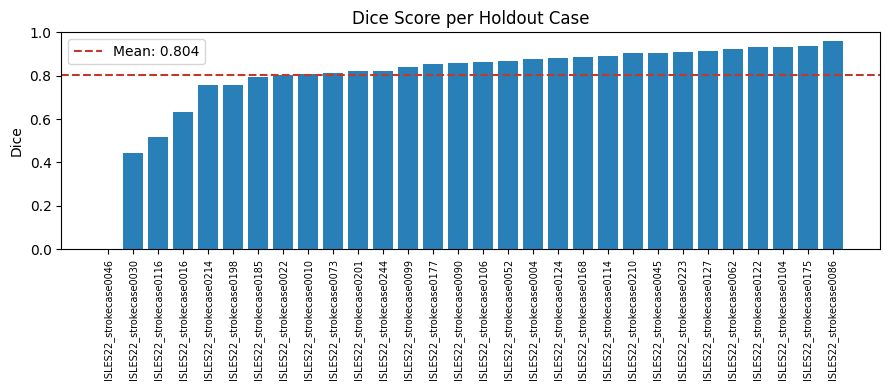

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
sorted_results = lesion_results.sort_values('dice')
ax.bar(sorted_results['case'], sorted_results['dice'], color='#2980b9')
ax.axhline(lesion_results['dice'].mean(), color='#c0392b', linestyle='--',
           label=f"Mean: {lesion_results['dice'].mean():.3f}")
ax.set_ylabel('Dice')
ax.set_title('Dice Score per Holdout Case')
ax.set_ylim(0, 1)
plt.xticks(rotation=90, fontsize=7)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Qualitative Visualization

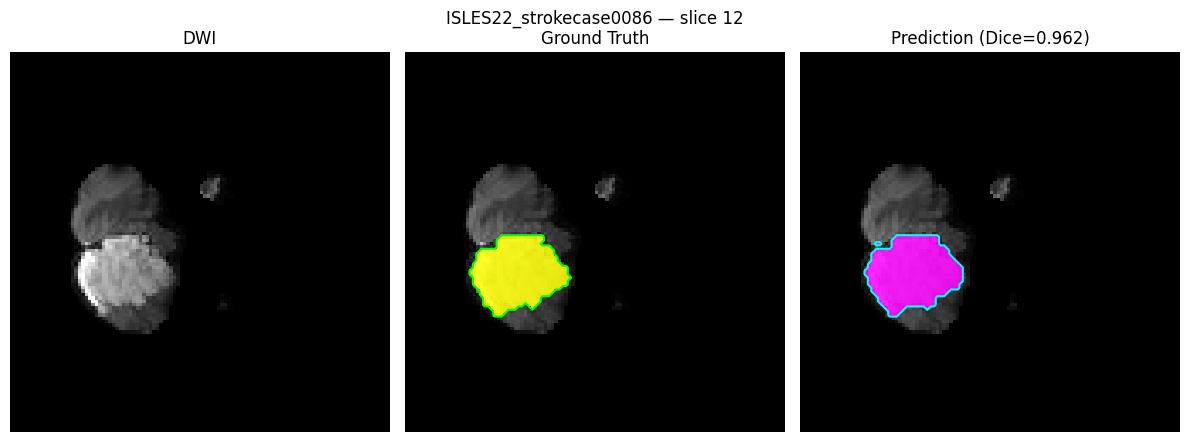

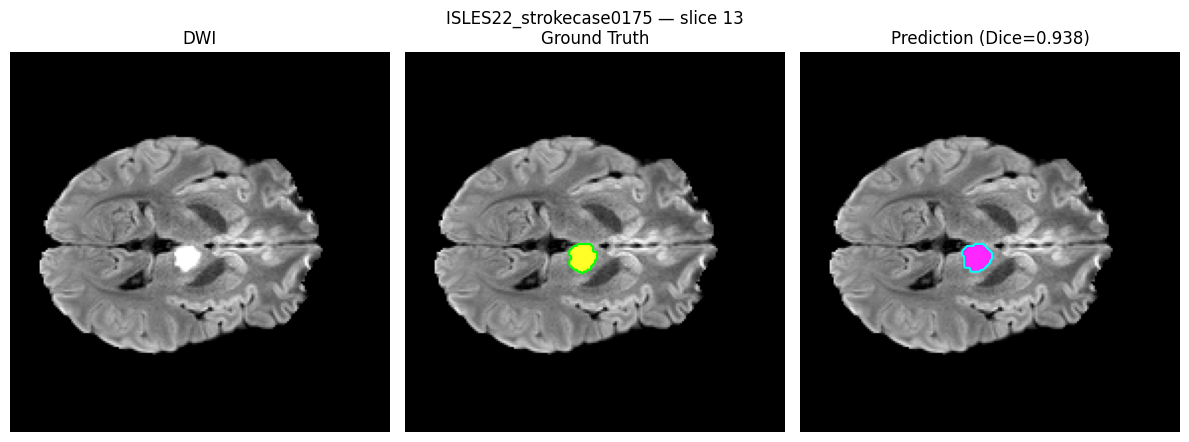

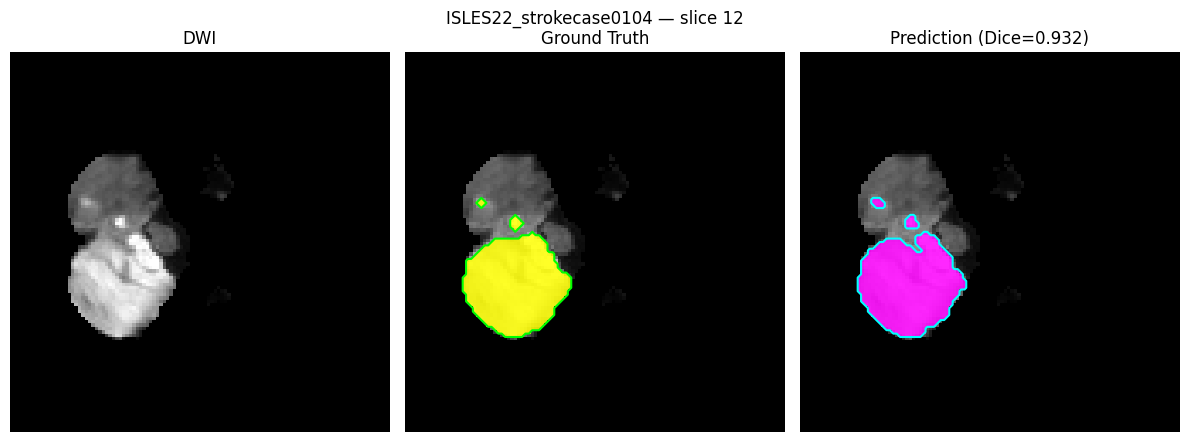

In [ ]:
def show_prediction(case_name, n_cases_max_slices=1):
    dwi_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz")).dataobj)
    gt_arr = np.asarray(nib.load(str(HOLDOUT_GT / f"{case_name}.nii.gz")).dataobj)
    pred_arr = np.asarray(nib.load(str(PREDICTIONS_DIR / f"{case_name}.nii.gz")).dataobj)

    best_slice = int(np.argmax(gt_arr.sum(axis=(0, 1))))
    dice = dice_score(pred_arr, gt_arr)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
    base = robust_normalize(dwi_arr[:, :, best_slice])

    axes[0].imshow(base, cmap='gray')
    axes[0].set_title('DWI')

    gt_slice = gt_arr[:, :, best_slice]
    axes[1].imshow(base, cmap='gray')
    axes[1].imshow(np.ma.masked_where(gt_slice == 0, gt_slice), cmap='spring', alpha=0.85, vmin=0, vmax=1)
    if gt_slice.max() > 0:
        axes[1].contour(gt_slice, levels=[0.5], colors='lime', linewidths=1.5)
    axes[1].set_title('Ground Truth')

    pred_slice = pred_arr[:, :, best_slice]
    axes[2].imshow(base, cmap='gray')
    axes[2].imshow(np.ma.masked_where(pred_slice == 0, pred_slice), cmap='cool', alpha=0.85, vmin=0, vmax=1)
    if pred_slice.max() > 0:
        axes[2].contour(pred_slice, levels=[0.5], colors='cyan', linewidths=1.5)
    axes[2].set_title(f'Prediction (Dice={dice:.3f})')

    for ax in axes:
        ax.axis('off')
    plt.suptitle(f"{case_name} — slice {best_slice}")
    plt.tight_layout()
    plt.show()

for case_name in lesion_results.sort_values('dice', ascending=False)['case'].head(3):
    show_prediction(case_name)


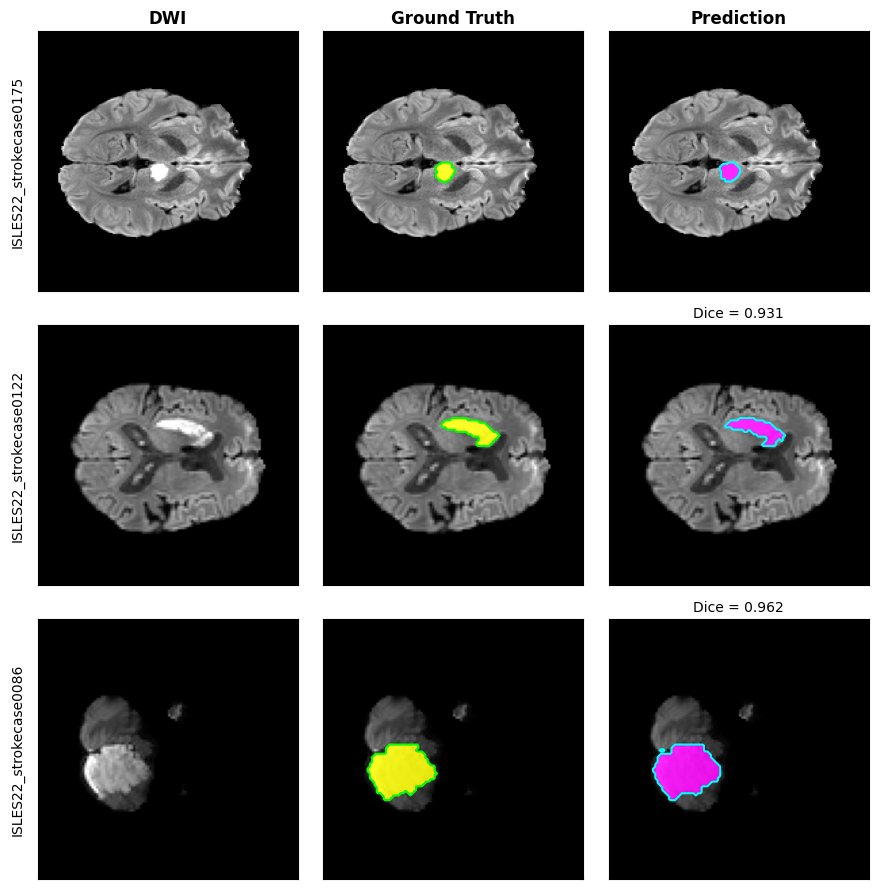

Saved: /content/drive/MyDrive/teknofest-dataset/isles22_prediction_example.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

def robust_normalize(arr, low_pct=1, high_pct=99):
    """Percentile-based contrast stretch for MRI display."""
    lo, hi = np.percentile(arr[arr > 0], [low_pct, high_pct]) if np.any(arr > 0) else (arr.min(), arr.max())
    clipped = np.clip(arr, lo, hi)
    if hi - lo < 1e-6:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((clipped - lo) / (hi - lo) * 255).astype(np.uint8)

def plot_case_row(ax_row, case_name):
    dwi_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz")).dataobj)
    gt_arr = np.asarray(nib.load(str(HOLDOUT_GT / f"{case_name}.nii.gz")).dataobj)
    pred_arr = np.asarray(nib.load(str(PREDICTIONS_DIR / f"{case_name}.nii.gz")).dataobj)

    best_slice = int(np.argmax(gt_arr.sum(axis=(0, 1))))
    dice = dice_score(pred_arr, gt_arr)
    base = robust_normalize(dwi_arr[:, :, best_slice])

    ax_row[0].imshow(base, cmap='gray')
    ax_row[0].set_ylabel(case_name, fontsize=10, rotation=90, labelpad=10)

    gt_slice = gt_arr[:, :, best_slice]
    ax_row[1].imshow(base, cmap='gray')
    ax_row[1].imshow(np.ma.masked_where(gt_slice == 0, gt_slice), cmap='spring', alpha=0.85, vmin=0, vmax=1)
    if gt_slice.max() > 0:
        ax_row[1].contour(gt_slice, levels=[0.5], colors='lime', linewidths=1.5)

    pred_slice = pred_arr[:, :, best_slice]
    ax_row[2].imshow(base, cmap='gray')
    ax_row[2].imshow(np.ma.masked_where(pred_slice == 0, pred_slice), cmap='cool', alpha=0.85, vmin=0, vmax=1)
    if pred_slice.max() > 0:
        ax_row[2].contour(pred_slice, levels=[0.5], colors='cyan', linewidths=1.5)
    ax_row[2].set_title(f'Dice = {dice:.3f}', fontsize=10)

    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

# Pick a few representative cases to stack (mix of strong results)
showcase_cases = ['ISLES22_strokecase0175', 'ISLES22_strokecase0122', 'ISLES22_strokecase0086']

fig, axes = plt.subplots(len(showcase_cases), 3, figsize=(9, 3 * len(showcase_cases)))
col_titles = ['DWI', 'Ground Truth', 'Prediction']

for row, case_name in enumerate(showcase_cases):
    plot_case_row(axes[row], case_name)

for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
fig.savefig(f'{OUT_DIR}/isles22_prediction_example.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT_DIR}/isles22_prediction_example.png")

In [ ]:
!pip install imageio scipy -q
import imageio.v2 as imageio
from scipy.ndimage import zoom
import io

UPSCALE = 4

def smooth_upscale(arr, factor=UPSCALE):
    return zoom(arr, factor, order=3)

def render_sequence_frame(dwi_slice, adc_slice, flair_slice, case_name, slice_idx, n_slices):
    dwi_up = smooth_upscale(robust_normalize(dwi_slice).astype(float))
    adc_up = smooth_upscale(robust_normalize(adc_slice).astype(float))
    flair_up = smooth_upscale(robust_normalize(flair_slice).astype(float))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), dpi=150)
    for ax, img, title in zip(axes, [dwi_up, adc_up, flair_up], ['DWI', 'ADC', 'FLAIR']):
        ax.imshow(np.clip(img, 0, 255), cmap='gray', interpolation='none')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f"{case_name} — slice {slice_idx}/{n_slices-1}", fontsize=13)
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return imageio.imread(buf)

def make_sequence_gif(case_name, out_dir=OUT_DIR):
    dwi_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz")).dataobj)
    adc_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0001.nii.gz")).dataobj)
    flair_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0002.nii.gz")).dataobj)
    n_slices = dwi_arr.shape[2]

    frames = [
        render_sequence_frame(dwi_arr[:, :, i], adc_arr[:, :, i], flair_arr[:, :, i], case_name, i, n_slices)
        for i in range(n_slices)
    ]

    gif_path = f'{out_dir}/{case_name}_sequences.gif'
    imageio.mimsave(gif_path, frames, duration=0.25)
    print(f"Saved ({n_slices} slices): {gif_path}")
    return gif_path

make_sequence_gif('ISLES22_strokecase0223')  # matches your comparison GIF for consistency

Saved (72 slices): /content/drive/MyDrive/teknofest-dataset/ISLES22_strokecase0223_sequences.gif


'/content/drive/MyDrive/teknofest-dataset/ISLES22_strokecase0223_sequences.gif'

In [ ]:
!pip install medpy -q
from medpy import metric
import pandas as pd

def compute_full_metrics(pred, gt, voxel_spacing):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)
    if gt_bin.sum() == 0:
        return None

    result = {
        'dice': metric.binary.dc(pred_bin, gt_bin),
        'iou_jaccard': metric.binary.jc(pred_bin, gt_bin),
        'sensitivity_recall': metric.binary.sensitivity(pred_bin, gt_bin),
        'precision': metric.binary.precision(pred_bin, gt_bin) if pred_bin.sum() > 0 else 0.0,
    }

    tn = np.sum((~pred_bin.astype(bool)) & (~gt_bin.astype(bool)))
    fp = np.sum(pred_bin.astype(bool) & (~gt_bin.astype(bool)))
    result['specificity'] = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    if pred_bin.sum() > 0:
        try:
            result['hausdorff95_mm'] = metric.binary.hd95(pred_bin, gt_bin, voxelspacing=voxel_spacing)
        except Exception:
            result['hausdorff95_mm'] = np.nan
    else:
        result['hausdorff95_mm'] = np.nan

    gt_vol = gt_bin.sum()
    pred_vol = pred_bin.sum()
    result['volumetric_similarity'] = 1 - abs(pred_vol - gt_vol) / (pred_vol + gt_vol) if (pred_vol + gt_vol) > 0 else np.nan

    return result

full_metrics = []
for case_name in holdout_case_names:
    gt_path = HOLDOUT_GT / f"{case_name}.nii.gz"
    pred_path = PREDICTIONS_DIR / f"{case_name}.nii.gz"
    if not pred_path.exists():
        continue

    gt_img = nib.load(str(gt_path))
    gt_arr = np.asarray(gt_img.dataobj)
    pred_arr = np.asarray(nib.load(str(pred_path)).dataobj)
    spacing = gt_img.header.get_zooms()[:3]

    m = compute_full_metrics(pred_arr, gt_arr, spacing)
    if m is not None:
        m['case'] = case_name
        full_metrics.append(m)

metrics_df = pd.DataFrame(full_metrics)
cols = ['case', 'dice', 'iou_jaccard', 'sensitivity_recall', 'specificity', 'precision', 'hausdorff95_mm', 'volumetric_similarity']
metrics_df = metrics_df[cols]

print(metrics_df.round(3))
print("\n--- Mean values ---")
print(metrics_df[cols[1:]].mean().round(3))

metrics_df.to_csv(f'{OUT_DIR}/isles22_full_metrics.csv', index=False)
print(f"\nSaved: {OUT_DIR}/isles22_full_metrics.csv")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/tmp/ipykernel_161779/1683054773.py:32: RuntimeWarning:

overflow encountered in scalar subtract



                      case   dice  iou_jaccard  sensitivity_recall  \
0   ISLES22_strokecase0004  0.878        0.782               0.829   
1   ISLES22_strokecase0010  0.808        0.678               0.755   
2   ISLES22_strokecase0016  0.634        0.464               0.500   
3   ISLES22_strokecase0022  0.804        0.673               0.693   
4   ISLES22_strokecase0030  0.442        0.284               0.297   
5   ISLES22_strokecase0045  0.906        0.828               0.854   
6   ISLES22_strokecase0046  0.000        0.000               0.000   
7   ISLES22_strokecase0052  0.869        0.768               0.845   
8   ISLES22_strokecase0062  0.923        0.858               0.965   
9   ISLES22_strokecase0073  0.814        0.687               0.754   
10  ISLES22_strokecase0086  0.962        0.926               0.956   
11  ISLES22_strokecase0090  0.859        0.754               0.814   
12  ISLES22_strokecase0099  0.841        0.726               0.869   
13  ISLES22_strokeca

In [ ]:
results = []
for case_name in holdout_case_names:
    gt_path = HOLDOUT_GT / f"{case_name}.nii.gz"
    pred_path = PREDICTIONS_DIR / f"{case_name}.nii.gz"
    if not pred_path.exists():
        print(f"WARNING: prediction missing for {case_name}")
        continue

    gt_arr = np.asarray(nib.load(str(gt_path)).dataobj)
    pred_arr = np.asarray(nib.load(str(pred_path)).dataobj)
    results.append({
        'case': case_name,
        'has_lesion': gt_arr.sum() > 0,
        'dice': round(dice_score(pred_arr, gt_arr), 3),
    })

results_df = pd.DataFrame(results)
lesion_results = results_df[results_df['has_lesion']]

print(results_df)
print(f"\nMean Dice (lesion-positive holdout cases): {lesion_results['dice'].mean():.3f}")
print(f"Median Dice: {lesion_results['dice'].median():.3f}")

results_df.to_csv(f'{OUT_DIR}/isles22_inference_results.csv', index=False)
print(f"\nSaved: {OUT_DIR}/isles22_inference_results.csv")

                      case  has_lesion   dice
0   ISLES22_strokecase0004        True  0.878
1   ISLES22_strokecase0010        True  0.808
2   ISLES22_strokecase0016        True  0.634
3   ISLES22_strokecase0022        True  0.804
4   ISLES22_strokecase0030        True  0.442
5   ISLES22_strokecase0045        True  0.906
6   ISLES22_strokecase0046        True  0.000
7   ISLES22_strokecase0052        True  0.869
8   ISLES22_strokecase0062        True  0.923
9   ISLES22_strokecase0073        True  0.814
10  ISLES22_strokecase0086        True  0.962
11  ISLES22_strokecase0090        True  0.859
12  ISLES22_strokecase0099        True  0.841
13  ISLES22_strokecase0104        True  0.932
14  ISLES22_strokecase0106        True  0.863
15  ISLES22_strokecase0114        True  0.890
16  ISLES22_strokecase0116        True  0.518
17  ISLES22_strokecase0122        True  0.931
18  ISLES22_strokecase0124        True  0.881
19  ISLES22_strokecase0127        True  0.915
20  ISLES22_strokecase0168        

In [ ]:
!pip install imageio -q
import imageio.v2 as imageio
import io

def render_frame(dwi_slice, gt_slice, pred_slice, dice, case_name, slice_idx, n_slices):
    base = robust_normalize(dwi_slice)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))

    axes[0].imshow(base, cmap='gray')
    axes[0].set_title('DWI')

    axes[1].imshow(base, cmap='gray')
    if gt_slice.max() > 0:
        axes[1].imshow(np.ma.masked_where(gt_slice == 0, gt_slice), cmap='spring', alpha=0.85, vmin=0, vmax=1)
        axes[1].contour(gt_slice, levels=[0.5], colors='lime', linewidths=1.5)
    axes[1].set_title('Ground Truth')

    axes[2].imshow(base, cmap='gray')
    if pred_slice.max() > 0:
        axes[2].imshow(np.ma.masked_where(pred_slice == 0, pred_slice), cmap='cool', alpha=0.85, vmin=0, vmax=1)
        axes[2].contour(pred_slice, levels=[0.5], colors='cyan', linewidths=1.5)
    axes[2].set_title(f'Prediction (Dice={dice:.3f})')

    for ax in axes:
        ax.axis('off')
    plt.suptitle(f"{case_name} — slice {slice_idx}/{n_slices-1}")
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100)
    plt.close(fig)
    buf.seek(0)
    return imageio.imread(buf)

def make_case_gif(case_name, out_dir='/content/drive/MyDrive/teknofest-dataset/isles22_gifs'):
    os.makedirs(out_dir, exist_ok=True)

    dwi_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz")).dataobj)
    gt_arr = np.asarray(nib.load(str(HOLDOUT_GT / f"{case_name}.nii.gz")).dataobj)
    pred_arr = np.asarray(nib.load(str(PREDICTIONS_DIR / f"{case_name}.nii.gz")).dataobj)

    dice = dice_score(pred_arr, gt_arr)
    n_slices = dwi_arr.shape[2]

    frames = []
    for i in range(n_slices):
        frame = render_frame(
            dwi_arr[:, :, i], gt_arr[:, :, i], pred_arr[:, :, i],
            dice, case_name, i, n_slices
        )
        frames.append(frame)

    gif_path = f'{out_dir}/{case_name}_comparison.gif'
    imageio.mimsave(gif_path, frames, duration=0.25)
    print(f"Kaydedildi ({n_slices} kesit): {gif_path}")
    return gif_path

gif_paths = []
for case_name in holdout_case_names:
    pred_path = PREDICTIONS_DIR / f"{case_name}.nii.gz"
    if not pred_path.exists():
        print(f"UYARI: tahmin yok, atlanıyor -> {case_name}")
        continue
    gif_paths.append(make_case_gif(case_name))

print(f"\nToplam {len(gif_paths)} GIF üretildi -> /content/drive/MyDrive/teknofest-dataset/isles22_gifs")

Kaydedildi (72 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0004_comparison.gif
Kaydedildi (72 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0010_comparison.gif
Kaydedildi (72 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0016_comparison.gif
Kaydedildi (73 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0022_comparison.gif
Kaydedildi (73 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0030_comparison.gif
Kaydedildi (73 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0045_comparison.gif
Kaydedildi (65 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0046_comparison.gif
Kaydedildi (73 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISLES22_strokecase0052_comparison.gif
Kaydedildi (72 kesit): /content/drive/MyDrive/teknofest-dataset/isles22_gifs/ISL

Shape: (112, 112, 72)
Voxel spacing (mm): (np.float32(2.0), np.float32(2.0), np.float32(2.0))
Min/Max değer: -12.1190851976375 1871.2129654681003


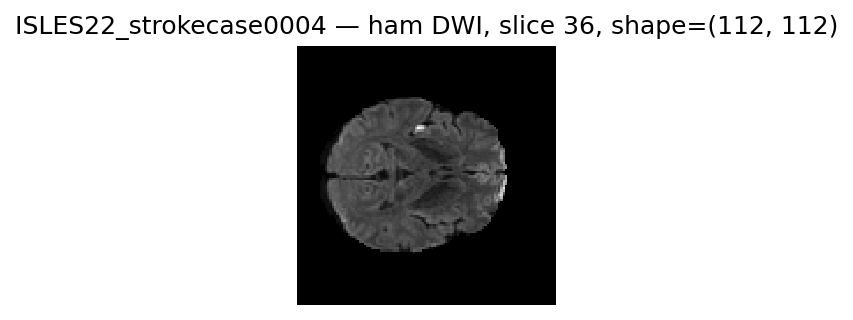

In [ ]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

# Herhangi bir holdout vakanın orijinal DWI dosyasını aç (hiç işlenmemiş hali)
case_name = holdout_case_names[0]  # istediğin vakayı seç
dwi_path = HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz"

img = nib.load(str(dwi_path))
data = img.get_fdata()

print("Shape:", data.shape)
print("Voxel spacing (mm):", img.header.get_zooms())
print("Min/Max değer:", data.min(), data.max())

# Orta kesiti, HİÇBİR interpolasyon/normalizasyon olmadan, 1:1 piksel oranında göster
mid_slice = data[:, :, data.shape[2] // 2]

fig, ax = plt.subplots(figsize=(mid_slice.shape[1]/50, mid_slice.shape[0]/50), dpi=150)
ax.imshow(mid_slice, cmap='gray', interpolation='none')  # interpolation='none' = tamamen ham piksel
ax.set_title(f"{case_name} — ham DWI, slice {data.shape[2]//2}, shape={mid_slice.shape}")
ax.axis('off')
plt.show()

In [ ]:
!pip install scikit-image plotly -q

import numpy as np
import nibabel as nib
from pathlib import Path
from skimage.measure import marching_cubes
import plotly.graph_objects as go

DATASET_ID = 3
HOLDOUT_DIR = Path('/content/isles22_holdout')
HOLDOUT_IMAGES = HOLDOUT_DIR / 'images'
HOLDOUT_GT = HOLDOUT_DIR / 'ground_truth'
PREDICTIONS_DIR = HOLDOUT_DIR / 'predictions'
OUT_DIR = '/content/drive/MyDrive/teknofest-dataset'

def dice_score(pred, gt):
    pred = (pred > 0).astype(np.uint8)
    gt = (gt > 0).astype(np.uint8)
    denom = np.sum(pred) + np.sum(gt)
    if denom == 0:
        return 1.0
    return 2.0 * np.sum(pred * gt) / denom

def make_3d_lesion_plot(case_name, spacing=(2.0, 2.0, 2.0), save=True):
    dwi_arr = np.asarray(nib.load(str(HOLDOUT_IMAGES / f"{case_name}_0000.nii.gz")).dataobj)
    gt_arr = np.asarray(nib.load(str(HOLDOUT_GT / f"{case_name}.nii.gz")).dataobj)
    pred_arr = np.asarray(nib.load(str(PREDICTIONS_DIR / f"{case_name}.nii.gz")).dataobj)

    fig = go.Figure()

    brain_mask = (dwi_arr > np.percentile(dwi_arr[dwi_arr > 0], 20)).astype(np.uint8)
    try:
        verts, faces, _, _ = marching_cubes(brain_mask, level=0.5, spacing=spacing)
        fig.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='lightgray', opacity=0.08, name='Brain (reference)'
        ))
    except Exception as e:
        print("Could not extract brain surface:", e)

    if gt_arr.sum() > 0:
        verts, faces, _, _ = marching_cubes(gt_arr, level=0.5, spacing=spacing)
        fig.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='limegreen', opacity=0.55, name='Ground Truth'
        ))

    if pred_arr.sum() > 0:
        verts, faces, _, _ = marching_cubes(pred_arr, level=0.5, spacing=spacing)
        fig.add_trace(go.Mesh3d(
            x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
            i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
            color='magenta', opacity=0.55, name='Model Prediction'
        ))

    dice = dice_score(pred_arr, gt_arr)
    fig.update_layout(
        title=f"{case_name} — 3D Lesion Visualization (Dice={dice:.3f})",
        scene=dict(aspectmode='data'),
        width=1000, height=800,
        legend=dict(x=0.02, y=0.98)
    )

    if save:
        html_path = f'{OUT_DIR}/{case_name}_3d.html'
        fig.write_html(html_path)
        print(f"HTML saved: {html_path}")

    fig.show()
    return fig

fig = make_3d_lesion_plot('ISLES22_strokecase0086')

HTML saved: /content/drive/MyDrive/teknofest-dataset/ISLES22_strokecase0086_3d.html


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Az önce hesapladığımız extended metrics tablosundan Dice'ları al
# (metrics_df zaten mevcutsa direkt kullan, yoksa results_df'ten türet)
dice_scores = metrics_df['dice'].values if 'metrics_df' in dir() else lesion_results['dice'].values
n = len(dice_scores)

print(f"Örneklem büyüklüğü (n): {n}")
print(f"Gözlemlenen ortalama Dice: {dice_scores.mean():.4f}")
print(f"Gözlemlenen medyan Dice: {np.median(dice_scores):.4f}")

# --- Bootstrap resampling ---
N_BOOTSTRAP = 10000
rng = np.random.default_rng(seed=42)

bootstrap_means = np.array([
    rng.choice(dice_scores, size=n, replace=True).mean()
    for _ in range(N_BOOTSTRAP)
])

ci_lower, ci_upper = np.percentile(bootstrap_means, [2.5, 97.5])
se = bootstrap_means.std()

print(f"\n--- Bootstrap Sonuçları ({N_BOOTSTRAP} yeniden örnekleme) ---")
print(f"Bootstrap ortalama: {bootstrap_means.mean():.4f}")
print(f"Standart hata (SE): {se:.4f}")
print(f"%95 Güven Aralığı: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Aralık genişliği: {ci_upper - ci_lower:.4f}")

Örneklem büyüklüğü (n): 30
Gözlemlenen ortalama Dice: 0.8037
Gözlemlenen medyan Dice: 0.8610

--- Bootstrap Sonuçları (10000 yeniden örnekleme) ---
Bootstrap ortalama: 0.8039
Standart hata (SE): 0.0344
%95 Güven Aralığı: [0.7269, 0.8619]
Aralık genişliği: 0.1350


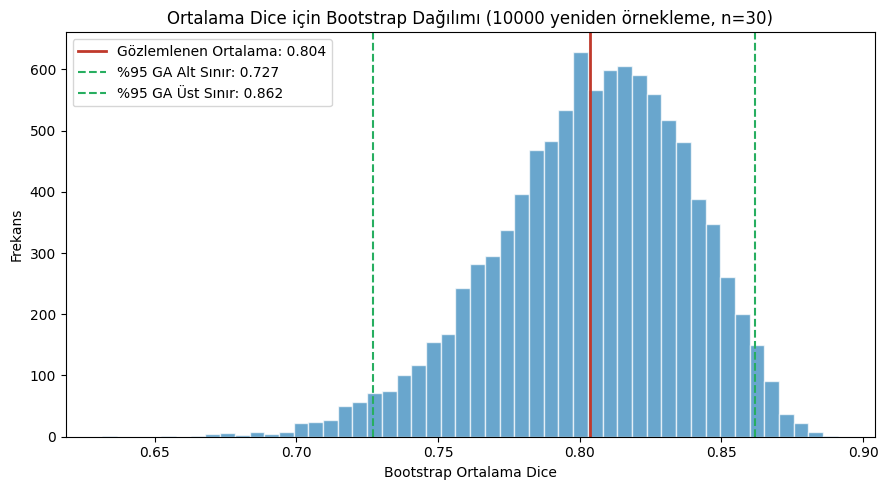

Kaydedildi.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(bootstrap_means, bins=50, color='#2980b9', alpha=0.7, edgecolor='white')
ax.axvline(dice_scores.mean(), color='#c0392b', linewidth=2, label=f'Gözlemlenen Ortalama: {dice_scores.mean():.3f}')
ax.axvline(ci_lower, color='#27ae60', linestyle='--', linewidth=1.5, label=f'%95 GA Alt Sınır: {ci_lower:.3f}')
ax.axvline(ci_upper, color='#27ae60', linestyle='--', linewidth=1.5, label=f'%95 GA Üst Sınır: {ci_upper:.3f}')

ax.set_xlabel('Bootstrap Ortalama Dice')
ax.set_ylabel('Frekans')
ax.set_title(f'Ortalama Dice için Bootstrap Dağılımı ({N_BOOTSTRAP} yeniden örnekleme, n={n})')
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig('/content/drive/MyDrive/teknofest-dataset/isles22_bootstrap_ci.png', dpi=150, bbox_inches='tight')
print("Kaydedildi.")

## Benchmark Context

Reported Dice scores on ISLES 2022 in the literature (full training, ensembled
models, official evaluation) commonly fall in the **0.75–0.87** range depending
on modality combination and architecture — e.g. DWI-only ≈0.84, DWI+ADC ≈0.86,
DWI+ADC+FLAIR ≈0.87 in one representative study; nnU-Net-based approaches in
challenge leaderboards report comparable figures. Results from this notebook
(single fold, `nnUNetTrainer_250epochs`, internal holdout rather than the
official hidden test set) should be read as a **development-stage baseline**,
not a challenge-leaderboard-equivalent number. For a stronger, publishable
result: train the full 1000-epoch trainer, use 5-fold ensembling via
`nnUNetv2_find_best_configuration`, and consider proper FLAIR-to-DWI
registration instead of simple resampling.

## Repository Suggestions

- Add a `requirements.txt` pinning `nnunetv2`, `nibabel`, `SimpleITK`.
- Store `isles22_eda_summary.csv` and `isles22_inference_results.csv` as
  tracked artifacts for reproducibility.
- Include this notebook's rendered output (with plots) directly in the repo
  README via exported PNGs, since GitHub does not always render notebook
  outputs reliably in previews.
